# Normalization experiments

Scratch notebook
Find sigma + gamma (and optionally CLAHE) that best matches the Zen normlization quality
Record the winning values and update `src/preprocess.py`.

In [1]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter
from skimage.exposure import equalize_adapthist

from src.io import load_stack

In [2]:
PROJECT_ROOT = Path('/Users/alicehong/projects/cellpose-biosensor')
# STACK_PATH   = PROJECT_ROOT / 'data/raw/16bit/Scene-01-20260416-C3M2_Tcol_1-A01Export-01_c1-4_stack.tif'
STACK_PATH   = PROJECT_ROOT / 'data/raw/16bit/Scene-04-20260416-C3M2_Tcol_3-A01Export-06_c1-4_stack.tif'

# ── Crop to inspect — change these to any region you want to test ─────────────
# CROP_Y, CROP_X, CROP_SIZE = 0, 0, 6000

stack = load_stack(STACK_PATH)
raw = stack[0]  # uint16 BFP
print(f'Raw range: {raw.min()} – {raw.max()}')

Raw range: 0 – 4714


In [3]:
def norm(img, sigma=0.0, gamma=1.0, low_pct=1, high_pct=99):
    x = img.astype(np.float32)
    if sigma > 0:
        x = gaussian_filter(x, sigma=sigma)
    lo, hi = np.percentile(x, low_pct), np.percentile(x, high_pct)
    x = np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)
    if gamma != 1.0:
        x = x ** gamma
    return x

def norm_clahe(img, sigma=0.0, kernel_size=64, clip_limit=0.02):
    x = img.astype(np.float32)
    if sigma > 0:
        x = gaussian_filter(x, sigma=sigma)
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)
    x = np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)
    return equalize_adapthist(x, kernel_size=kernel_size, clip_limit=clip_limit)

## Grid: sigma × gamma

Rows = smoothing (sigma), columns = gamma.  
Adjust the lists below then re-run.

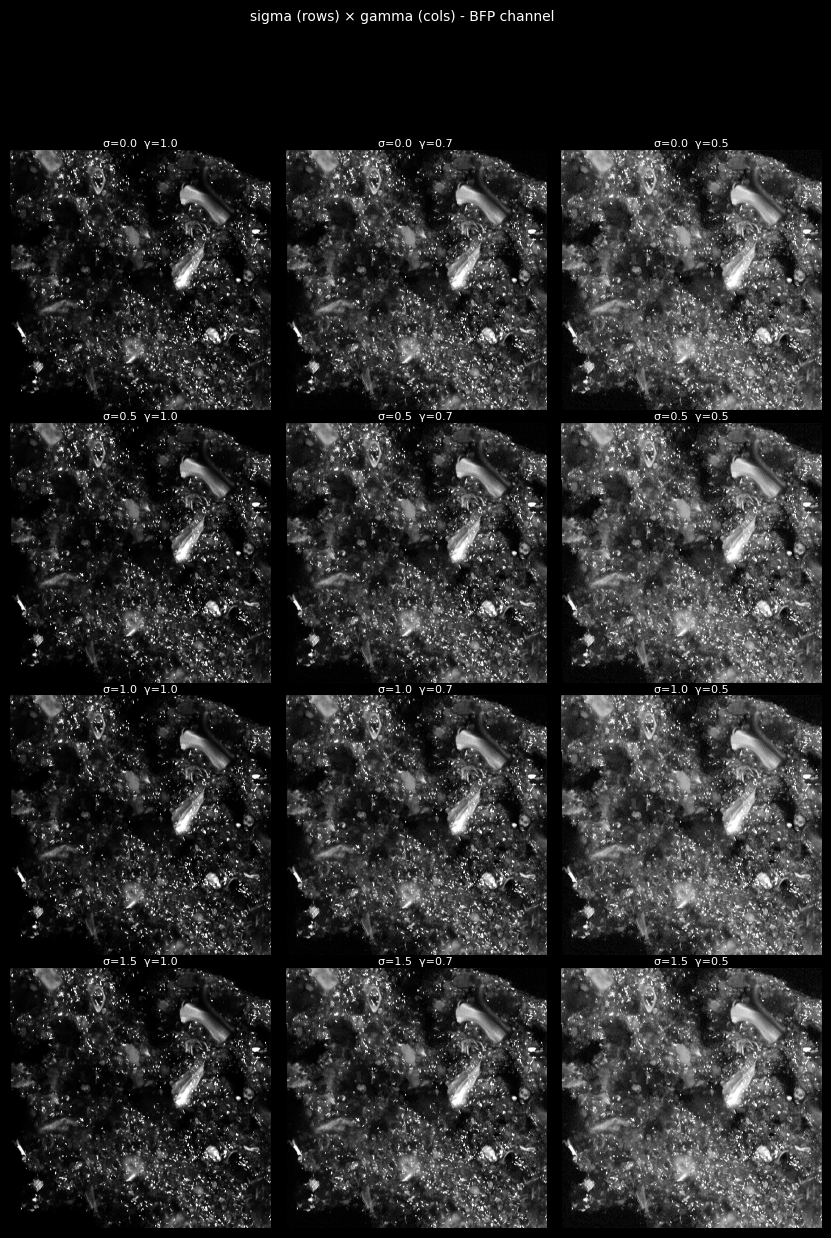

In [4]:
SIGMAS = [0.0, 0.5, 1.0, 1.5]
GAMMAS = [1.0, 0.7, 0.5]

fig, axes = plt.subplots(len(SIGMAS), len(GAMMAS),
                          figsize=(len(GAMMAS)*3.5, len(SIGMAS)*3.5),
                          facecolor='black')
fig.subplots_adjust(hspace=0.05, wspace=0.05)

for r, sigma in enumerate(SIGMAS):
    for c, gamma in enumerate(GAMMAS):
        ax = axes[r][c]
        ax.imshow(norm(raw, sigma=sigma, gamma=gamma), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        label = f'σ={sigma}  γ={gamma}'
        ax.set_title(label, color='white', fontsize=8, pad=2)

fig.suptitle('sigma (rows) × gamma (cols) - BFP channel', color='white', fontsize=10)
plt.savefig(PROJECT_ROOT / 'figures/qc/tmp_sigma_gamma_grid.png',
            dpi=120, bbox_inches='tight', facecolor='black')
plt.show()

## CLAHE variants

Rows = sigma, columns = CLAHE kernel size.

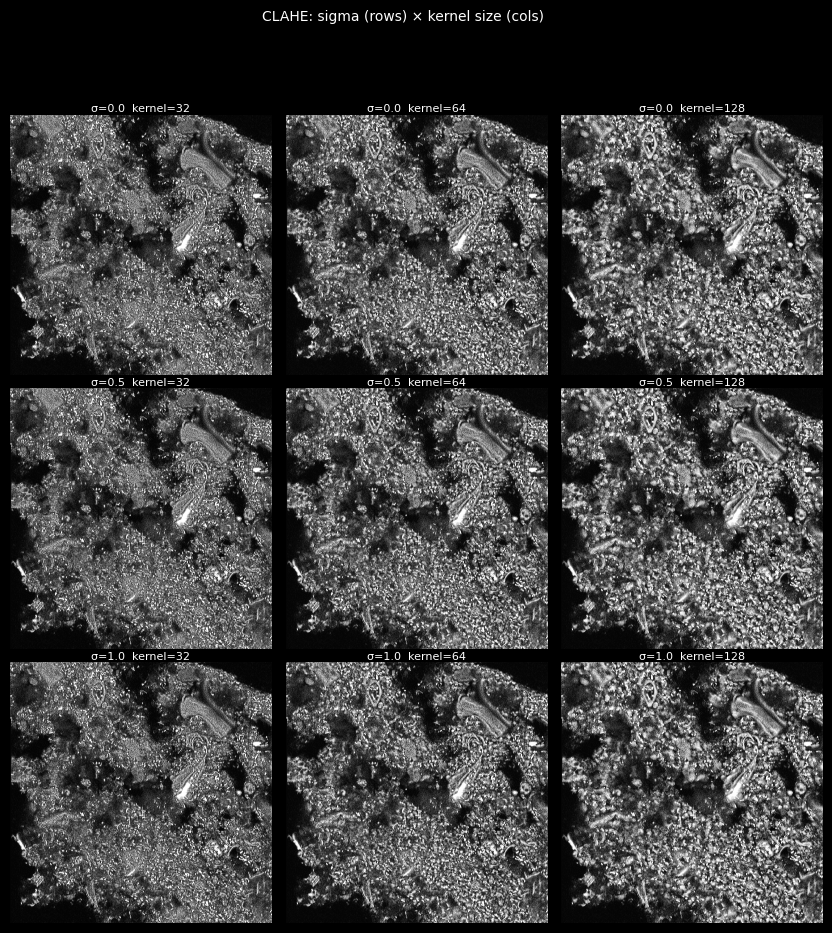

In [5]:
CLAHE_SIGMAS  = [0.0, 0.5, 1.0]
CLAHE_KERNELS = [32, 64, 128]

fig, axes = plt.subplots(len(CLAHE_SIGMAS), len(CLAHE_KERNELS),
                          figsize=(len(CLAHE_KERNELS)*3.5, len(CLAHE_SIGMAS)*3.5),
                          facecolor='black')
fig.subplots_adjust(hspace=0.05, wspace=0.05)

for r, sigma in enumerate(CLAHE_SIGMAS):
    for c, ks in enumerate(CLAHE_KERNELS):
        ax = axes[r][c]
        ax.imshow(norm_clahe(raw, sigma=sigma, kernel_size=ks), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        ax.set_title(f'σ={sigma}  kernel={ks}', color='white', fontsize=8, pad=2)

fig.suptitle('CLAHE: sigma (rows) × kernel size (cols)', color='white', fontsize=10)
plt.savefig(PROJECT_ROOT / 'figures/qc/tmp_clahe_grid.png',
            dpi=120, bbox_inches='tight', facecolor='black')
plt.show()

## Side-by-side: current vs chosen

Once you've picked values, set them below and compare directly.  
This is the cell to screenshot next to the Zen RGB export.

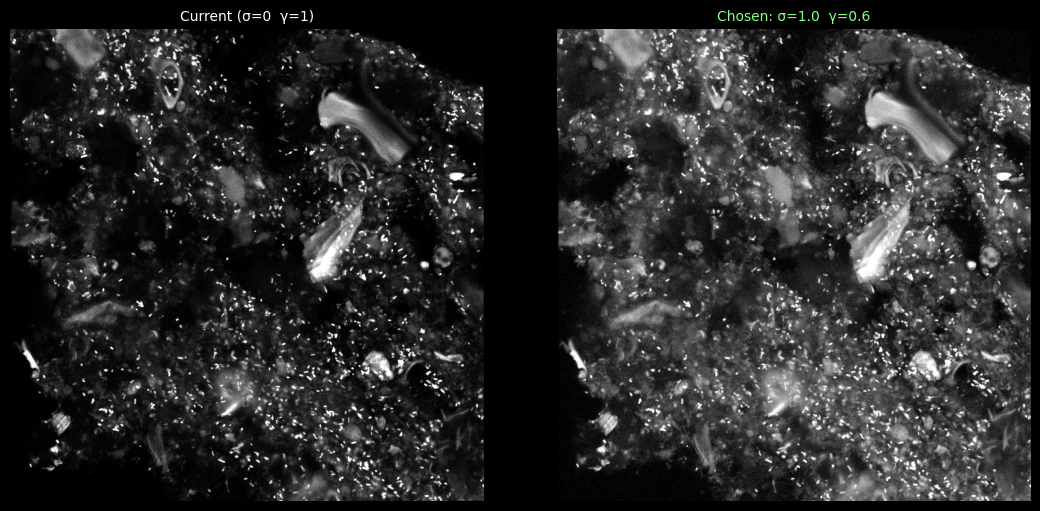


Record these values for src/preprocess.py:
  smooth_sigma = 1.0
  gamma        = 0.6


In [6]:
# ── SET YOUR CHOSEN VALUES HERE ───────────────────────────────────────────────
CHOSEN_SIGMA = 1.0
CHOSEN_GAMMA = 0.6
USE_CLAHE    = False   # set True to use CLAHE instead of gamma
CLAHE_KERNEL = 64
# ─────────────────────────────────────────────────────────────────────────────

current  = norm(raw, sigma=0.0, gamma=1.0)   # what we use now
if USE_CLAHE:
    chosen = norm_clahe(raw, sigma=CHOSEN_SIGMA, kernel_size=CLAHE_KERNEL)
    chosen_label = f'σ={CHOSEN_SIGMA}  CLAHE kernel={CLAHE_KERNEL}'
else:
    chosen = norm(raw, sigma=CHOSEN_SIGMA, gamma=CHOSEN_GAMMA)
    chosen_label = f'σ={CHOSEN_SIGMA}  γ={CHOSEN_GAMMA}'

fig, axes = plt.subplots(1, 2, figsize=(11, 5), facecolor='black')
axes[0].imshow(current, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Current (σ=0  γ=1)', color='white', fontsize=10)
axes[0].axis('off')
axes[1].imshow(chosen, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Chosen: {chosen_label}', color='#88ff88', fontsize=10)
axes[1].axis('off')

plt.tight_layout(pad=0.3)
plt.savefig(PROJECT_ROOT / 'figures/qc/tmp_chosen_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

print(f'\nRecord these values for src/preprocess.py:')
print(f'  smooth_sigma = {CHOSEN_SIGMA}')
if USE_CLAHE:
    print(f'  use_clahe    = True')
    print(f'  clahe_kernel = {CLAHE_KERNEL}')
else:
    print(f'  gamma        = {CHOSEN_GAMMA}')